# Project CV2: Robust Head Pose Estimation Under Facial Occlusions

Project developed by Antonio Vila Leis and Enric Baixauli Casañ.

## Introduction

This project addresses the challenge of accurately estimating head posture in the presence of facial occlusions, such as masks and sunglasses.

We work with the TokenHPE model, which gave the best results in the *models_demo.ipynb* due to its superior Transformer technology. Our objective in this notebook is to be able to improve its performance when tested with occluded images. In order to do that, we modified an existing datset that the model had not seen during training (**I2Head dataset**), we obtained the landmark points of each image and afterwards applied different occlusion techniques, all the steps can be observed in *occlusion_demo.ipynb*.

Our step by step planification is the following:

1. **Data Separation and Occlusion Pipeline Configuration**
   - Partition the dataset into independent training, validation and test subsets grouped strictly by subject identity to guarantee a person-independent evaluation and prevent data leakage.
   - Configure a dynamic data pipeline using random synthetic occlusions (`occlusion_mode="random"`) for training and validation loaders to enhance model generalization.
   - Organize the unseen test set into four test categories for exhaustive evaluation: **RAW** (unoccluded faces), **MASK** (surgical masks), **GLASSES** (sunglasses), and **BOTH** (combined occlusions).

2. **Baseline Performance Evaluation**
   - Load the `TokenHPE` architecture and initialize it with its pre-trained checkpoint weights.
   - Benchmark this baseline model against all four `I2Head` test configurations to document the exact performance degradation caused by facial occlusions before any targeted adaptation.

3. **Fine-Tuning Implementation Strategies**
   - **Full Network Adaptation:** Train the complete set of parameters end-to-end using the occlusion-augmented dataset to adjust the core transformer layers to missing facial features.
   - **Parameter-Efficient Fine-Tuning (LoRA):** Run an alternative, efficient optimization by freezing the base transformer layers and exclusively training Low-Rank Adaptation (LoRA) matrices, the orientation blocks (`Ori_blocks`), and the final prediction head (`mlp_head`).

4. **Comparative Analysis and Validation**
   - Assess the Mean Absolute Error (MAE), Root Mean Squared Error (RMSE) and Normalized Root Mean Squared Error (NRMSE) across Yaw, Pitch and Roll angles for both fine-tuning strategies across all four test splits.

5. **Failure Cases**
   - Find and demonstrate that the model has weaknesses with respect to certain types of cases.

In [1]:
import os
import torch
import torchvision.transforms as T
from torch.utils.data import DataLoader
import sys
from dataset import I2HeadDataset
import utils
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
import time
from models.utils_hpe import compute_euler_angles_from_rotation_matrices, draw_axis
import cv2
import torch._dynamo
torch._dynamo.config.suppress_errors = True
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
utils.set_global_seed(123)

if torch.cuda.is_available():
    device_name = "cuda"
elif torch.backends.mps.is_available():
    device_name = "mps"
else:
    device_name = "cpu"
    
device = torch.device(device_name)
print(f"Code runs in {device}")

Code runs in cuda


## Data Loading

In this code cell, we will perform the dataset parsing and splitting, as well as the DataLoader construction. Our source files are organized in a "raw" directory, where each image filename contains the subject ID as a prefix (e.g., "p01_image_01_raw.png"). We will parse these filenames to group images by subject, then perform a subject-level split into training, validation and test sets. Finally, we will create DataLoaders for each set, including separate evaluation tracks for the test set based on occlusion modes. 


In [ ]:
import os
import random
from torch.utils.data import DataLoader
import torchvision.transforms as T

RAW_DATASET_DIR = "./dataset/test/raw"
BATCH_SIZE = 32

transforms_pipeline = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])

subjects_dict = {}

# Parse baseline references from the raw directory
for file in os.listdir(RAW_DATASET_DIR):
    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
        filename_no_ext = os.path.splitext(file)[0]
        
        # Extract subject prefix (e.g., pulls 'p01' from 'p01_image_01_raw' or 'p01_image_01')
        subject_id = filename_no_ext.split("_")[0] 
        
        full_path = os.path.join(RAW_DATASET_DIR, file)
        
        if subject_id not in subjects_dict:
            subjects_dict[subject_id] = []
        subjects_dict[subject_id].append(full_path)

unique_subjects = sorted(list(subjects_dict.keys()))
print(f"Total number of people found: {len(unique_subjects)}")

# Subject-level Split (9 Train / 1 Val / 2 Test)
random.seed(123)
random.shuffle(unique_subjects)

train_subj = unique_subjects[:9]
val_subj   = [unique_subjects[9]]
test_subj  = unique_subjects[10:]

print(f"Split people -> Train: {train_subj} | Val: {val_subj} | Test: {test_subj}")

# Gather lists of paths
train_paths = []
for subj in train_subj:
    train_paths.extend(subjects_dict[subj])

val_paths = []
for subj in val_subj:
    val_paths.extend(subjects_dict[subj])

test_paths = []
for subj in test_subj:
    test_paths.extend(subjects_dict[subj])

print(f"Split images -> Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

# Instantiate Datasets
train_dataset = I2HeadDataset(image_paths_or_dir=train_paths, transform=transforms_pipeline, occlusion_mode="random")
val_dataset   = I2HeadDataset(image_paths_or_dir=val_paths, transform=transforms_pipeline, occlusion_mode="random")

# Define the 4 isolated evaluation tracks matching the test subject
test_raw     = I2HeadDataset(image_paths_or_dir=test_paths, transform=transforms_pipeline, occlusion_mode="raw")
test_mask    = I2HeadDataset(image_paths_or_dir=test_paths, transform=transforms_pipeline, occlusion_mode="mask")
test_glasses = I2HeadDataset(image_paths_or_dir=test_paths, transform=transforms_pipeline, occlusion_mode="glasses")
test_both    = I2HeadDataset(image_paths_or_dir=test_paths, transform=transforms_pipeline, occlusion_mode="both")

# Construct DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

raw_loader     = DataLoader(test_raw, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
mask_loader    = DataLoader(test_mask, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
glasses_loader = DataLoader(test_glasses, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
both_loader    = DataLoader(test_both, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print("DataLoaders built successfully!")

Total number of people found: 12
Split people -> Train: ['p08', 'p06', 'p10', 'p03', 'p04', 'p09', 'p12', 'p11', 'p07'] | Val: ['p02'] | Test: ['p05', 'p01']
Split images -> Train: 738 | Val: 82 | Test: 164
DataLoaders built successfully!


After the data loading, we load the model with the weights from [its original source](https://github.com/zc2023/TokenHPE). 

In [6]:
sys.path.append("./models")

from token_hpe import TokenHPE

model = TokenHPE(depth=3)
checkpoint = torch.load("./weights/TokenHPEv1-ViTB-224_224-lyr3.tar", map_location="cpu")

state_dict = checkpoint["model_state_dict"]

model.load_state_dict(state_dict, strict=True)

model = model.to(device)

==> Add Sine PositionEmbedding~


==> Add Sine PositionEmbedding~


/tmp/ipykernel_12661/1715322118.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("./weights/TokenHPEv1-ViTB-224_224-lyr3.tar", map_location="cpu")

We then test this baseline model with the four different test sets to observe its results.

In [5]:
model.eval()

print("\n-> Test 1/4: RAW")
mae_r, rmse_r, nrmse_r = utils.evaluate_metrics(model, raw_loader, device)

print("\n-> Test 2/4: MASK")
mae_m, rmse_m, nrmse_m = utils.evaluate_metrics(model, mask_loader, device)

print("\n-> Test 3/4: GLASSES")
mae_g, rmse_g, nrmse_g = utils.evaluate_metrics(model, glasses_loader, device)

print("\n-> Test 4/4: BOTH")
mae_b, rmse_b, nrmse_b = utils.evaluate_metrics(model, both_loader, device)

def print_results(test_name, mae, rmse, nrmse):
    print(f"\n{test_name}")
    print(f"  MAE -> Yaw: {mae['yaw']} | Pitch: {mae['pitch']} | Roll: {mae['roll']} | Total: {mae['total']}")
    print(f"  RMSE -> Yaw: {rmse['yaw']} | Pitch: {rmse['pitch']} | Roll: {rmse['roll']} | Total: {rmse['total']}")
    print(f"  NRMSE -> Yaw: {nrmse['yaw']} | Pitch: {nrmse['pitch']} | Roll: {nrmse['roll']} | Total: {nrmse['total']}")

print_results("Test RAW:", mae_r, rmse_r, nrmse_r)
print_results("Test MASK:", mae_m, rmse_m, nrmse_m)
print_results("Test GLASSES:", mae_g, rmse_g, nrmse_g)
print_results("Test BOTH:", mae_b, rmse_b, nrmse_b)


-> Test 1/4: RAW


Evaluating: 100%|██████████| 6/6 [00:02<00:00,  2.96it/s]



-> Test 2/4: MASK


Evaluating: 100%|██████████| 6/6 [00:01<00:00,  3.34it/s]



-> Test 3/4: GLASSES


Evaluating: 100%|██████████| 6/6 [00:01<00:00,  3.28it/s]



-> Test 4/4: BOTH


Evaluating: 100%|██████████| 6/6 [00:01<00:00,  3.32it/s]


Test RAW:
  MAE -> Yaw: 0.12259228527545929 | Pitch: 0.1570236086845398 | Roll: 0.1368132382631302 | Total: 0.1388096958398819
  RMSE -> Yaw: 0.15527920424938202 | Pitch: 0.20764875411987305 | Roll: 0.15655317902565002 | Total: 0.1731603890657425
  NRMSE -> Yaw: 0.2784444987773895 | Pitch: 1.370741367340088 | Roll: 0.38516727089881897 | Total: 0.6781177520751953

Test MASK:
  MAE -> Yaw: 0.3934626281261444 | Pitch: 0.15674397349357605 | Roll: 0.08211416006088257 | Total: 0.21077358722686768
  RMSE -> Yaw: 0.4482223391532898 | Pitch: 0.2048194706439972 | Roll: 0.10380588471889496 | Total: 0.25228258967399597
  NRMSE -> Yaw: 0.8037460446357727 | Pitch: 1.352064609527588 | Roll: 0.25539326667785645 | Total: 0.8037346005439758

Test GLASSES:
  MAE -> Yaw: 0.17473526298999786 | Pitch: 0.14715471863746643 | Roll: 0.14066772162914276 | Total: 0.15418590605258942
  RMSE -> Yaw: 0.20160265266895294 | Pitch: 0.18720123171806335 | Roll: 0.1644745022058487 | Total: 0.18442612886428833
  NRMSE -> 

We can appreciate how, as expected, the best results were obtained in the raw dataset, as it is in this one where the model has more information from the faces to make its predictions. The glasses dataset followed closely, as it is the lightest occlusion, while the worst performers were the datasets where the mask was involved as a big portion of the face is unrecognizable.

# Fine-Tunning

In this section, we will load the model again and re-train it using our new occluded dataset. 

Our goal is to adapt the network's attention mechanisms so that they are not affected by missing or altered facial features and to recover the estimation accuracy lost in the benchmark tests.

### Total Fine-Tunning

In this first approach, we unfreeze all layers to fully adapt the network end-to-end to the occluded data. This is a heavy resource consuming approach, as all the parameters must be updated during training, significantly increasing both memory usage and computation time.

In [10]:
criterion = nn.L1Loss()

optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5, verbose=True)

epochs = 5
best_val_loss = float('inf')

In [11]:
def train_model(epochs=epochs, model=model, name = "base", train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, device=device):
    global best_val_loss
    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        start_time = time.time()

        # Training
        model.train()
        running_train_loss = 0.0
    
        for imgs, poses in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            imgs, poses = imgs.to(device), poses.to(device)
            
            optimizer.zero_grad()
            
            predictions = model(imgs)
            
            if isinstance(predictions, (tuple, list)):
                pred_mat = predictions[0]
                pred_angles = compute_euler_angles_from_rotation_matrices(pred_mat, use_gpu=True)
                pred_angles = pred_angles.to(device)
            else:
                pred_angles = predictions
                
            loss = criterion(pred_angles, poses)
            
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * imgs.size(0)
            
        epoch_train_loss = running_train_loss / len(train_dataset)
        train_losses.append(epoch_train_loss)
        
        # Validation
        model.eval()
        running_val_loss = 0.0
        
        with torch.no_grad():
            for imgs, poses in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                imgs, poses = imgs.to(device), poses.to(device)
                
                predictions = model(imgs)
                
                if isinstance(predictions, (tuple, list)):
                    pred_mat = predictions[0]
                    pred_angles = compute_euler_angles_from_rotation_matrices(pred_mat, use_gpu=True)
                    pred_angles = pred_angles.to(device)
                else:
                    pred_angles = predictions
                    
                loss = criterion(pred_angles, poses)
                running_val_loss += loss.item() * imgs.size(0)
                
        epoch_val_loss = running_val_loss / len(val_dataset)
        val_losses.append(epoch_val_loss)
        
        scheduler.step(epoch_val_loss)
        
        epoch_time = time.time() - start_time
        
        print(f"\nEpoch {epoch+1}/{epochs} completed in {epoch_time:.0f}s")
        print(f"Train Loss (MAE radians): {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            save_path = "./weights/TokenHPE_Finetuned_" + name + ".pth"
            torch.save(model.state_dict(), save_path)
            print("Best model updated")
        else:
            print("\n")
    return train_losses, val_losses

In [16]:
l_trainC,l_valC = train_model(name="Complete", epochs=epochs, model=model, optimizer=optimizer, scheduler=scheduler)

Epoch 1/5 [Val]: 100%|██████████| 3/3 [00:37<00:00, 12.59s/it]



Epoch 1/5 completed in 141s
Train Loss (MAE radians): 0.1078 | Val Loss: 0.1055
Best model updated


Epoch 2/5 [Val]: 100%|██████████| 3/3 [00:35<00:00, 11.91s/it]



Epoch 2/5 completed in 121s
Train Loss (MAE radians): 0.0787 | Val Loss: 0.1386




Epoch 3/5 [Val]: 100%|██████████| 3/3 [00:35<00:00, 12.00s/it]



Epoch 3/5 completed in 124s
Train Loss (MAE radians): 0.0478 | Val Loss: 0.1386




Epoch 4/5 [Val]: 100%|██████████| 3/3 [00:36<00:00, 12.02s/it]



Epoch 4/5 completed in 124s
Train Loss (MAE radians): 0.0395 | Val Loss: 0.1399




Epoch 5/5 [Val]: 100%|██████████| 3/3 [00:36<00:00, 12.18s/it]


Epoch 5/5 completed in 125s
Train Loss (MAE radians): 0.0279 | Val Loss: 0.1199




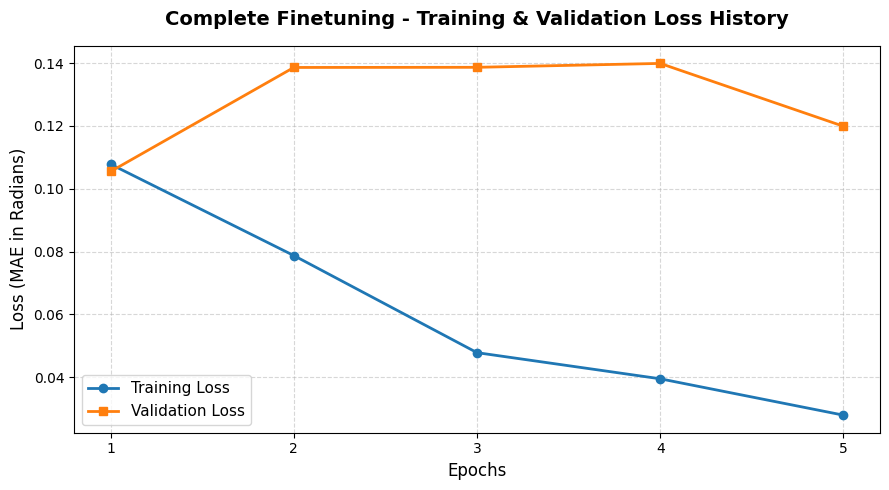

In [17]:
utils.plot_training_history(l_trainC, l_valC, model_name="Complete Finetuning")

In [5]:
sys.path.append("./models")

from token_hpe import TokenHPE

model_C = TokenHPE(depth=3)
checkpoint_path = "./weights/TokenHPE_Finetuned_Complete.pth"
checkpoint = torch.load(checkpoint_path, map_location="cpu")

state_dict = checkpoint.get("model_state_dict", checkpoint)
model_C.load_state_dict(state_dict, strict=True)

model_C = model_C.to(device)
model_C.eval()

print("\n-> Test 1/4: RAW")
mae_r, rmse_r, nrmse_r = utils.evaluate_metrics(model_C, raw_loader, device)

print("\n-> Test 2/4: MASK")
mae_m, rmse_m, nrmse_m = utils.evaluate_metrics(model_C, mask_loader, device)

print("\n-> Test 3/4: GLASSES")
mae_g, rmse_g, nrmse_g = utils.evaluate_metrics(model_C, glasses_loader, device)

print("\n-> Test 4/4: BOTH")
mae_b, rmse_b, nrmse_b = utils.evaluate_metrics(model_C, both_loader, device)

def print_results(test_name, mae, rmse, nrmse):
    print(f"\n{test_name}")
    print(f"  MAE -> Yaw: {mae['yaw']} | Pitch: {mae['pitch']} | Roll: {mae['roll']} | Total: {mae['total']}")
    print(f"  RMSE -> Yaw: {rmse['yaw']} | Pitch: {rmse['pitch']} | Roll: {rmse['roll']} | Total: {rmse['total']}")
    print(f"  NRMSE -> Yaw: {nrmse['yaw']} | Pitch: {nrmse['pitch']} | Roll: {nrmse['roll']} | Total: {nrmse['total']}")

print_results("Test RAW:", mae_r, rmse_r, nrmse_r)
print_results("Test MASK:", mae_m, rmse_m, nrmse_m)
print_results("Test GLASSES:", mae_g, rmse_g, nrmse_g)
print_results("Test BOTH:", mae_b, rmse_b, nrmse_b)


==> Add Sine PositionEmbedding~


/tmp/ipykernel_4926/2091663313.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location="cpu")



-> Test 1/4: RAW


Evaluating: 100%|██████████| 6/6 [00:02<00:00,  2.72it/s]



-> Test 2/4: MASK


...


-> Test 3/4: GLASSES


Evaluating: 100%|██████████| 6/6 [00:01<00:00,  3.16it/s]



-> Test 4/4: BOTH


Evaluating: 100%|██████████| 6/6 [00:01<00:00,  3.19it/s]


Test RAW:
  MAE -> Yaw: 0.1750580370426178 | Pitch: 0.027453340590000153 | Roll: 0.08902306854724884 | Total: 0.0971781387925148
  RMSE -> Yaw: 0.21441468596458435 | Pitch: 0.03340359404683113 | Roll: 0.10928547382354736 | Total: 0.11903458833694458
  NRMSE -> Yaw: 0.3844854235649109 | Pitch: 0.2205054759979248 | Roll: 0.2688747048377991 | Total: 0.2912885248661041

Test MASK:
  MAE -> Yaw: 0.17263053357601166 | Pitch: 0.0256873220205307 | Roll: 0.08785606175661087 | Total: 0.09539130330085754
  RMSE -> Yaw: 0.2111346274614334 | Pitch: 0.03138992562890053 | Roll: 0.10799624025821686 | Total: 0.11684026569128036
  NRMSE -> Yaw: 0.37860366702079773 | Pitch: 0.20721274614334106 | Roll: 0.2657027840614319 | Total: 0.28383973240852356

Test GLASSES:
  MAE -> Yaw: 0.1722838282585144 | Pitch: 0.02763570472598076 | Roll: 0.08915305882692337 | Total: 0.09635753184556961
  RMSE -> Yaw: 0.21121805906295776 | Pitch: 0.033491961658000946 | Roll: 0.10899009555578232 | Total: 0.11790004372596741
  N

**Analysis**

As can be seen, the model adapts perfectly to the new dataset, reducing the error in the raw test (from a RMSE of 0.17 to 0.11). But the most relevant point here is that the error reduction is proportionally greater in the occluded areas compared to the raw data  (e.g. in "mask" we obtained a RMSE in the baseline of 0.25 and now we have 0.11), demonstrating that the model is not only adapting to the new dataset but is also able to ignore occlusions and achieve very competitive results.

### LoRA

In this second approach we keep the core transformer frozen and only training the LoRA components and orientation blocks.
This significantly reduces the computational cost, since the majority of the model’s parameters remain fixed and only a small set of trainable adapters is optimized.

In [5]:
sys.path.append("./models")

from token_hpe import TokenHPE

model_lora = TokenHPE(depth=3)
checkpoint = torch.load("./weights/TokenHPEv1-ViTB-224_224-lyr3.tar", map_location="cpu")

state_dict = checkpoint["model_state_dict"]

model_lora.load_state_dict(state_dict, strict=True)

model_lora = model_lora.to(device)

==> Add Sine PositionEmbedding~


C:\Users\enric\AppData\Local\Temp\ipykernel_8740\2471208752.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("./weights/TokenHPEv1-ViTB-224_224-ly

In [6]:
for name, m in model_lora.feature_extractor.named_modules():
    if 'qkv' in name or 'attn' in name or 'proj' in name:
        print(name)

patch_embed.proj
blocks.0.attn
blocks.0.attn.qkv
blocks.0.attn.attn_drop
blocks.0.attn.proj
blocks.0.attn.proj_drop
blocks.1.attn
blocks.1.attn.qkv
blocks.1.attn.attn_drop
blocks.1.attn.proj
blocks.1.attn.proj_drop
blocks.2.attn
blocks.2.attn.qkv
blocks.2.attn.attn_drop
blocks.2.attn.proj
blocks.2.attn.proj_drop
blocks.3.attn
blocks.3.attn.qkv
blocks.3.attn.attn_drop
blocks.3.attn.proj
blocks.3.attn.proj_drop
blocks.4.attn
blocks.4.attn.qkv
blocks.4.attn.attn_drop
blocks.4.attn.proj
blocks.4.attn.proj_drop
blocks.5.attn
blocks.5.attn.qkv
blocks.5.attn.attn_drop
blocks.5.attn.proj
blocks.5.attn.proj_drop
blocks.6.attn
blocks.6.attn.qkv
blocks.6.attn.attn_drop
blocks.6.attn.proj
blocks.6.attn.proj_drop
blocks.7.attn
blocks.7.attn.qkv
blocks.7.attn.attn_drop
blocks.7.attn.proj
blocks.7.attn.proj_drop
blocks.8.attn
blocks.8.attn.qkv
blocks.8.attn.attn_drop
blocks.8.attn.proj
blocks.8.attn.proj_drop
blocks.9.attn
blocks.9.attn.qkv
blocks.9.attn.attn_drop
blocks.9.attn.proj
blocks.9.attn.pro

In [7]:
from peft import LoraConfig, get_peft_model

config = LoraConfig(
    r=16, 
    lora_alpha=32, 
    target_modules=["qkv"], # Targets the self-attention projections in the ViT blocks
    lora_dropout=0.1,
    bias="none"
)

model_lora.feature_extractor = get_peft_model(model_lora.feature_extractor, config)
model_lora = model_lora.to(device)

In [8]:
# We completely freeze all the parameters of the base model
for param in model_lora.parameters():
    param.requires_grad = False

# We only unfreeze the parameters that contain "lora" and the downstream task modules
for name, param in model_lora.named_parameters():
    if "lora" in name or "Ori_blocks" in name or "mlp_head" in name:
        param.requires_grad = True

# Here we can see how many parameters will actually be trained
trainable_params = sum(p.numel() for p in model_lora.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_lora.parameters())
print(f"Trainable Parameters: {trainable_params:,} out of {total_params:,} "
      f"({trainable_params/total_params:.2%})")

Trainable Parameters: 1,231,636 out of 87,034,906 (1.42%)


Only 1.42% of the parameters are actually trained in this experiment with LoRA.

In [ ]:
criterion = nn.L1Loss()

optimizer_lora = optim.AdamW(
    filter(lambda p: p.requires_grad, model_lora.parameters()),
    lr=5e-5,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_lora, mode='min', patience=3, factor=0.5, verbose=True
)

best_val_loss = float('inf')
epochs = 10
best_val_loss = float('inf')
l_trainL, l_valL = train_model(epochs=epochs, model=model_lora, optimizer=optimizer_lora, scheduler=scheduler, name="LoRA")

Epoch 1/10 [Val]: 100%|██████████| 3/3 [00:31<00:00, 10.36s/it]



Epoch 1/10 completed in 73s
Train Loss (MAE radians): 0.0902 | Val Loss: 0.1086
Best model updated


Epoch 2/10 [Val]: 100%|██████████| 3/3 [00:27<00:00,  9.27s/it]



Epoch 2/10 completed in 67s
Train Loss (MAE radians): 0.0692 | Val Loss: 0.1272




Epoch 3/10 [Val]: 100%|██████████| 3/3 [00:28<00:00,  9.51s/it]


...


Epoch 8/10 completed in 67s
Train Loss (MAE radians): 0.0379 | Val Loss: 0.1208




Epoch 9/10 [Val]: 100%|██████████| 3/3 [00:28<00:00,  9.54s/it]



Epoch 9/10 completed in 67s
Train Loss (MAE radians): 0.0348 | Val Loss: 0.1172




Epoch 10/10 [Val]: 100%|██████████| 3/3 [00:28<00:00,  9.45s/it]


Epoch 10/10 completed in 68s
Train Loss (MAE radians): 0.0317 | Val Loss: 0.1146




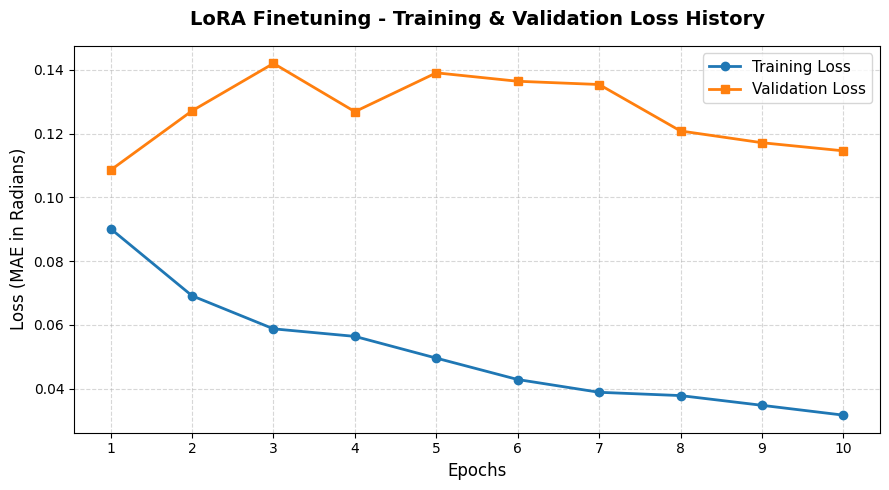

In [ ]:
utils.plot_training_history(l_trainL, l_valL, model_name="LoRA Finetuning")

In [ ]:
model_lora.eval()

print("\n-> Test 1/4: RAW")
mae_r, rmse_r, nrmse_r = utils.evaluate_metrics(model_lora, raw_loader, device)

print("\n-> Test 2/4: MASK")
mae_m, rmse_m, nrmse_m = utils.evaluate_metrics(model_lora, mask_loader, device)

print("\n-> Test 3/4: GLASSES")
mae_g, rmse_g, nrmse_g = utils.evaluate_metrics(model_lora, glasses_loader, device)

print("\n-> Test 4/4: BOTH")
mae_b, rmse_b, nrmse_b = utils.evaluate_metrics(model_lora, both_loader, device)

def print_results(test_name, mae, rmse, nrmse):
    print(f"\n{test_name}")
    print(f"  MAE -> Yaw: {mae['yaw']} | Pitch: {mae['pitch']} | Roll: {mae['roll']} | Total: {mae['total']}")
    print(f"  RMSE -> Yaw: {rmse['yaw']} | Pitch: {rmse['pitch']} | Roll: {rmse['roll']} | Total: {rmse['total']}")
    print(f"  NRMSE -> Yaw: {nrmse['yaw']} | Pitch: {nrmse['pitch']} | Roll: {nrmse['roll']} | Total: {nrmse['total']}")

print_results("Test RAW:", mae_r, rmse_r, nrmse_r)
print_results("Test MASK:", mae_m, rmse_m, nrmse_m)
print_results("Test GLASSES:", mae_g, rmse_g, nrmse_g)
print_results("Test BOTH:", mae_b, rmse_b, nrmse_b)


-> Test 1/4: RAW


Evaluating: 100%|██████████| 6/6 [00:07<00:00,  1.23s/it]



-> Test 2/4: MASK


Evaluating: 100%|██████████| 6/6 [00:07<00:00,  1.24s/it]



-> Test 3/4: GLASSES


Evaluating: 100%|██████████| 6/6 [00:07<00:00,  1.23s/it]



-> Test 4/4: BOTH


Evaluating: 100%|██████████| 6/6 [00:07<00:00,  1.23s/it]


Test RAW:
  MAE -> Yaw: 0.08296426385641098 | Pitch: 0.06999862939119339 | Roll: 0.13724708557128906 | Total: 0.09673666208982468
  RMSE -> Yaw: 0.10611246526241302 | Pitch: 0.0831989049911499 | Roll: 0.17222923040390015 | Total: 0.12051353603601456
  NRMSE -> Yaw: 0.2610681354999542 | Pitch: 0.5492168068885803 | Roll: 0.3088390529155731 | Total: 0.3730413019657135

Test MASK:
  MAE -> Yaw: 0.10897228121757507 | Pitch: 0.08377358317375183 | Roll: 0.18774935603141785 | Total: 0.12683174014091492
  RMSE -> Yaw: 0.12751173973083496 | Pitch: 0.09466183185577393 | Roll: 0.22702261805534363 | Total: 0.1497320681810379
  NRMSE -> Yaw: 0.31371670961380005 | Pitch: 0.6248864531517029 | Roll: 0.4070937931537628 | Total: 0.44856563210487366

Test GLASSES:
  MAE -> Yaw: 0.09687181562185287 | Pitch: 0.0594983845949173 | Roll: 0.12404234707355499 | Total: 0.09347084909677505
  RMSE -> Yaw: 0.12359333038330078 | Pitch: 0.07050073146820068 | Roll: 0.1537213921546936 | Total: 0.11593848466873169
  NRM

**Analysis**

While LoRA demonstrates competitive performance, full fine-tuning provides strictly better results, specifically outperforming LoRA in the "mask" and "both" categories. Consequently, we discarded the LoRA approach and selected full fine-tuning as our definitive model.

## Qualitative analysis

This section serves as as visual evaluation insted of a metrics-based one.

In [3]:
sys.path.append("./models")
from token_hpe import TokenHPE

model_baseline_q = TokenHPE(depth=3)
checkpoint = torch.load("./weights/TokenHPEv1-ViTB-224_224-lyr3.tar", map_location="cpu")
sd = checkpoint.get("model_state_dict", checkpoint)
model_baseline_q.load_state_dict(sd, strict=True)
model_baseline_q = model_baseline_q.to(device).eval()

model_finetuned_q = TokenHPE(depth=3)
checkpoint = torch.load("./weights/TokenHPE_Finetuned_Complete.pth", map_location="cpu")
sd = checkpoint.get("model_state_dict", checkpoint)
model_finetuned_q.load_state_dict(sd, strict=True)
model_finetuned_q = model_finetuned_q.to(device).eval()

/home/anton/miniconda3/envs/cv2-2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


==> Add Sine PositionEmbedding~


/tmp/ipykernel_38398/2182980330.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("./weights/TokenHPEv1-ViTB-224_224-lyr3.tar", map_location="cpu")

==> Add Sine PositionEmbedding~


/tmp/ipykernel_38398/2182980330.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("./weights/TokenHPE_Finetuned_Complete.pth", map_location="cpu")

Real -> Pitch:3.39 | Yaw:13.86 | Roll:20.96
Baseline -> Pitch:-0.97 Yaw:-26.22 Roll:30.62 | MAE: 18.04°
Fine-tuned -> Pitch:1.34 Yaw:-1.01 Roll:16.53 | MAE: 7.12°


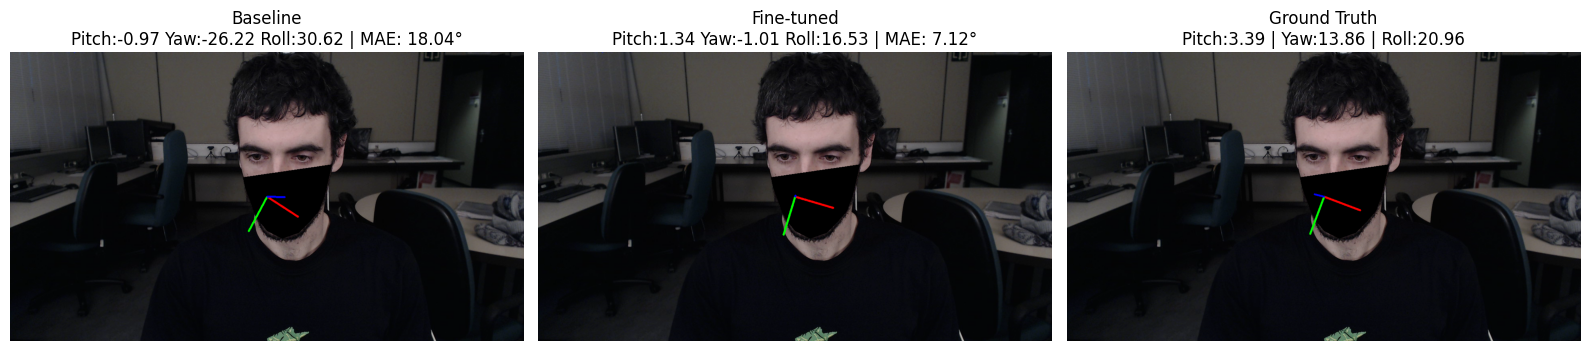

In [ ]:
IMAGE_PATH = "./dataset/test/mask/p05_image_56_mask.png"

utils.qualitative_eval(IMAGE_PATH, device, model_baseline_q, model_finetuned_q)

## Failure Cases

In this section we analyze two different failure cases of our model.

### 1. Person size

When evaluating the same image of an individual at three different decreasing scales, displaying it against both a white background and an office background, we observed that the smaller the face, the greater the error. This is explained by the fact that, when the face is large, the ViT distributes key facial features across multiple tokens, allowing the self-attention mechanism to accurately model their relationship. However, when the face is small, these features collapse within a smaller number of tokens, depriving the network of the necessary spatial resolution and degrading the pose estimation.


In [3]:
sys.path.append("./models")

from token_hpe import TokenHPE

model_C = TokenHPE(depth=3)
checkpoint_path = "./weights/TokenHPE_Finetuned_Complete.pth"
checkpoint = torch.load(checkpoint_path, map_location="cpu")

state_dict = checkpoint.get("model_state_dict", checkpoint)
model_C.load_state_dict(state_dict, strict=True)

model_C = model_C.to(device)

/home/anton/miniconda3/envs/cv2-2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


==> Add Sine PositionEmbedding~


/tmp/ipykernel_4990/3117501556.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location="cpu")



Ground Truth   | Pitch:  +0.36° | Yaw:  +0.10° | Roll: +14.73°
Image Version    | Pitch (Error)   | Yaw (Error)     | Roll (Error)    | MAE    
1. Base Image    |  +1.61 ( 1.26°) |  -1.61 ( 1.71°) | +17.06 ( 2.33°) |  1.76°
2. Mod Image     |  +2.26 ( 1.91°) |  -2.10 ( 2.20°) | +16.96 ( 2.23°) |  2.11°
3. Third Image   |  +2.43 ( 2.08°) |  -2.66 ( 2.76°) | +16.71 ( 1.97°) |  2.27°



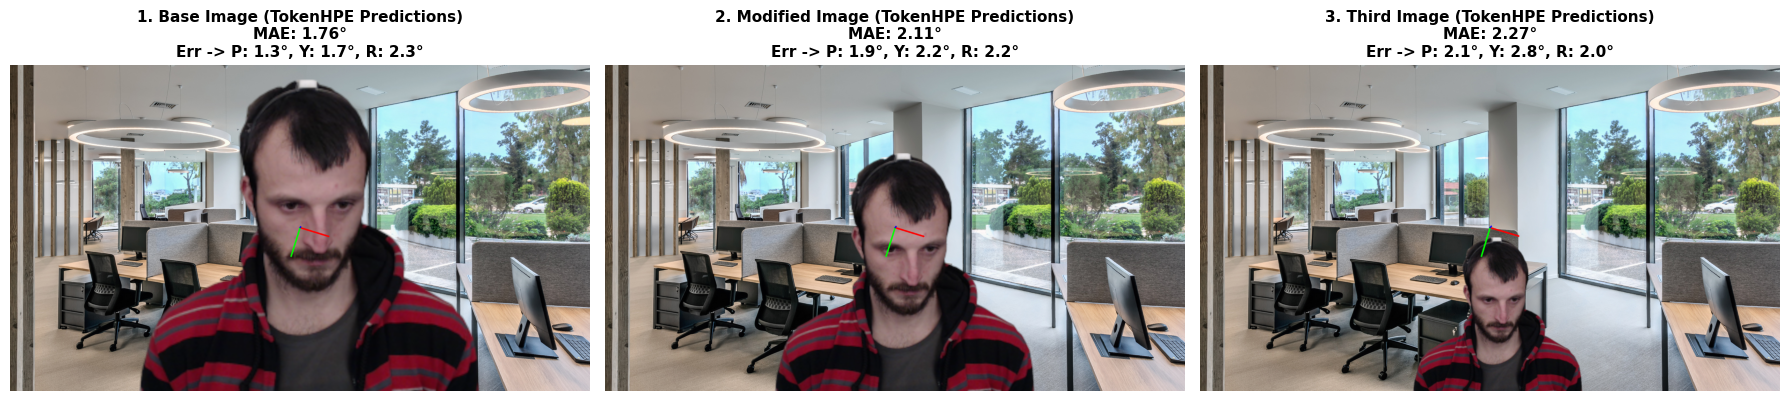


Ground Truth   | Pitch:  -1.04° | Yaw:  +0.65° | Roll: +14.08°
Image Version    | Pitch (Error)   | Yaw (Error)     | Roll (Error)    | MAE    
1. Base Image    |  +1.12 ( 2.17°) |  -1.28 ( 1.92°) | +16.12 ( 2.05°) |  2.05°
2. Mod Image     |  +1.73 ( 2.77°) |  -1.23 ( 1.87°) | +16.16 ( 2.08°) |  2.24°
3. Third Image   |  +2.34 ( 3.38°) |  -1.03 ( 1.68°) | +16.67 ( 2.59°) |  2.55°



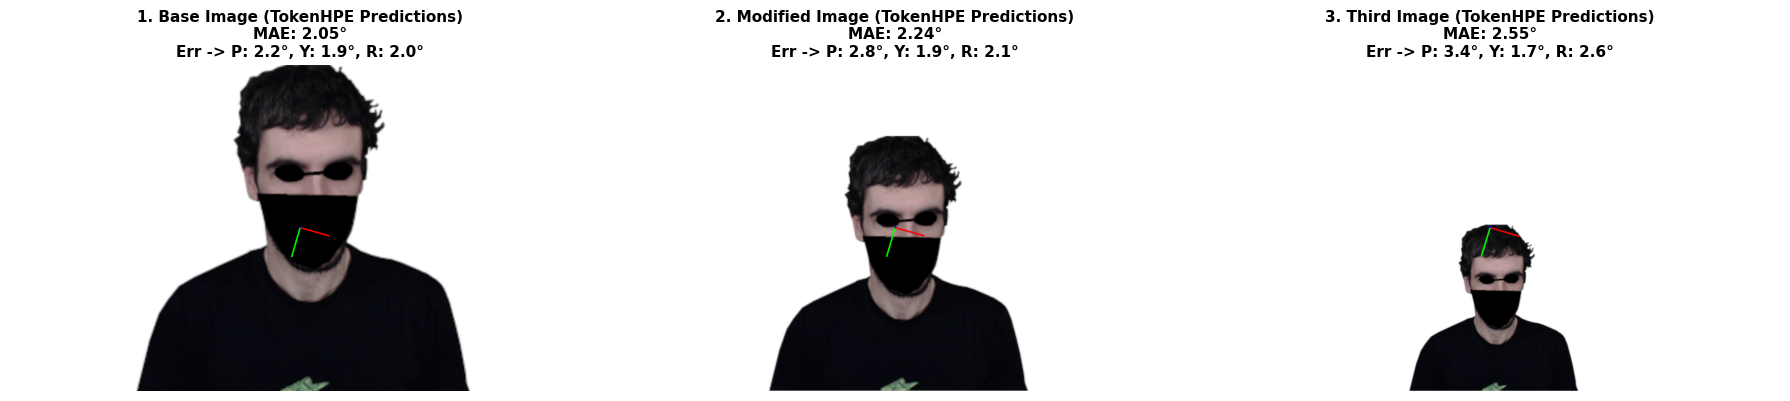

In [29]:
img_path = "./test_failure/resize/p01_size1_raw.png"
img_path2 = "./test_failure/resize/p01_size2_raw.png"
img_path3 = "./test_failure/resize/p01_size3_raw.png"
mat_path = "./test_failure/resize/p01_size.mat"
utils.evaluate_paired_images_thpe(img_path, img_path2, img_path3, mat_path, model_C)

img_path = "./test_failure/resize/p04_size1_both.png"
img_path2 = "./test_failure/resize/p04_size2_both.png"
img_path3 = "./test_failure/resize/p04_size3_both.png"
mat_path = "./test_failure/resize/p04_size.mat"
utils.evaluate_paired_images_thpe(img_path, img_path2, img_path3, mat_path, model_C)

### 2. Different occlusions

In this second case, we evaluated the model against occlusions that were not present in the training set, such as microphones or headphones. In these scenarios, the model's performance degraded, demonstrating that, having been exposed only to two specific types of occlusions, it lacks the ability to generalize to new ones.


Ground Truth   | Pitch:  +0.36° | Yaw:  +0.10° | Roll: +14.73°
Image Version    | Pitch (Error)   | Yaw (Error)     | Roll (Error)    | MAE    
1. Base Image    |  +1.32 ( 0.96°) |  -1.46 ( 1.56°) | +16.56 ( 1.83°) |  1.45°
2. Mod Image     |  +1.34 ( 0.98°) |  -1.15 ( 1.25°) | +16.38 ( 1.65°) |  1.29°
3. Third Image   |  +1.61 ( 1.25°) |  -1.71 ( 1.81°) | +16.76 ( 2.02°) |  1.70°



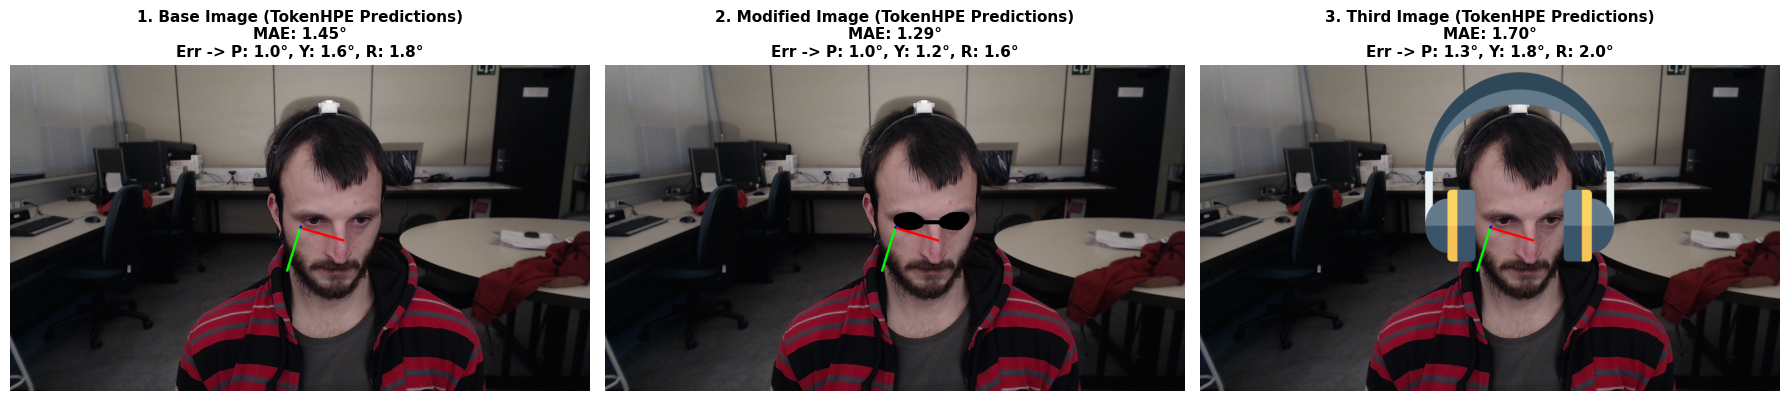


Ground Truth   | Pitch:  +1.58° | Yaw: +10.75° | Roll: +15.85°
Image Version    | Pitch (Error)   | Yaw (Error)     | Roll (Error)    | MAE    
1. Base Image    |  +1.15 ( 0.43°) |  -1.42 (12.17°) | +16.30 ( 0.45°) |  4.35°
2. Mod Image     |  +1.22 ( 0.37°) |  -1.22 (11.97°) | +16.27 ( 0.41°) |  4.25°
3. Third Image   |  +2.98 ( 1.40°) |  -1.00 (11.75°) | +16.75 ( 0.90°) |  4.68°



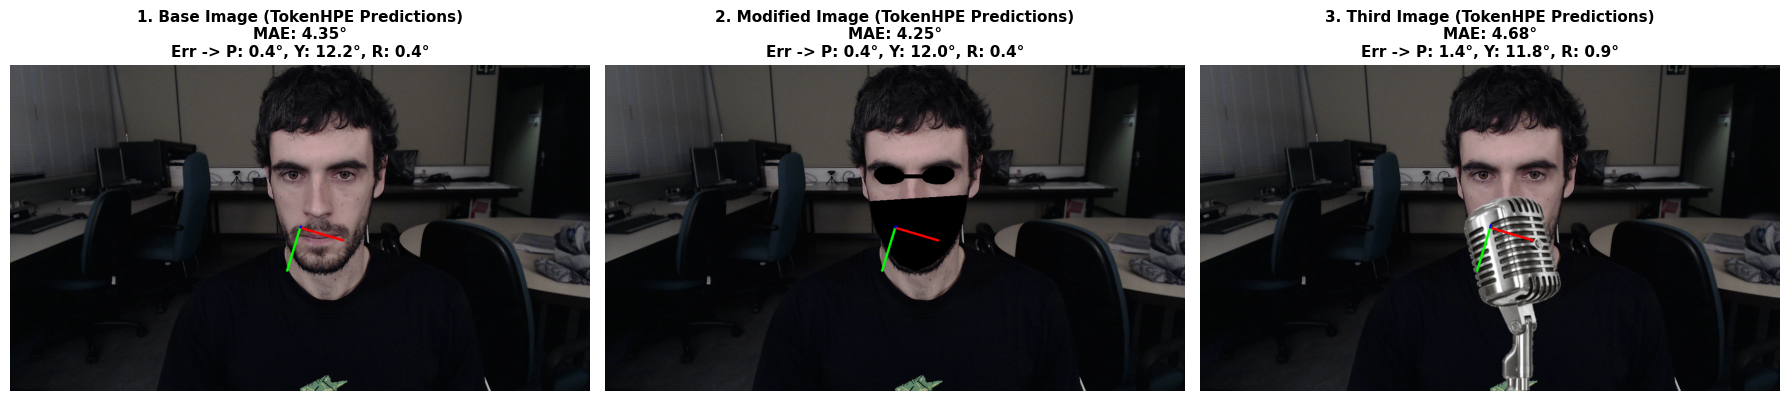

In [27]:
img_path = "./test_failure/other_occlusions/p01_hf1.png"
img_path2 = "./test_failure/other_occlusions/p01_hf2.png"
img_path3 = "./test_failure/other_occlusions/p01_hf3.png"
mat_path = "./test_failure/other_occlusions/p01_hf.mat"
utils.evaluate_paired_images_thpe(img_path, img_path2, img_path3, mat_path, model_C)

img_path = "./test_failure/other_occlusions/p02_micro1.png"
img_path2 = "./test_failure/other_occlusions/p02_micro2.png"
img_path3 = "./test_failure/other_occlusions/p02_micro3.png"
mat_path = "./test_failure/other_occlusions/p02_micro.mat"
utils.evaluate_paired_images_thpe(img_path, img_path2, img_path3, mat_path, model_C)

**AI Note:**

Please note that during the development of this project, LLMs were used as a support tool to ensure code quality and readability. Specifically, AI was used for:

- Error debugging.

- Organizing the project structure.

- Translating comments and documentation.

- General code review and formatting.

- Assistance with unfamiliar libraries and general doubts.